### ***Phase 1***
- Data Loading & Schema Handling

In [ ]:
%pip install pyspark

In [2]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("COVID19-Analytics-Pipeline").getOrCreate()

In [4]:
# Load all datasets

full_grouped = spark.read.csv("datasets/full_grouped.csv", header=True, inferSchema=True)
covid_clean = spark.read.csv("datasets/covid_19_clean_complete.csv", header=True, inferSchema=True)
country_latest = spark.read.csv("datasets/country_wise_latest.csv", header=True, inferSchema=True)
day_wise = spark.read.csv("datasets/day_wise.csv", header=True, inferSchema=True)
usa_county = spark.read.csv("datasets/usa_county_wise.csv", header=True, inferSchema=True)
worldometer = spark.read.csv("datasets/worldometer_data.csv", header=True, inferSchema=True)

In [ ]:
# Schema of each dataset

print("FULL GROUPED SCHEMA")
full_grouped.printSchema()

print("COVID CLEAN SCHEMA")
covid_clean.printSchema()

print("COUNTRY LATEST SCHEMA")
country_latest.printSchema()

print("DAY WISE SCHEMA")
day_wise.printSchema()

print("USA COUNTY SCHEMA")
usa_county.printSchema()

print("WORLDMETER SCHEMA")
worldometer.printSchema()

FULL GROUPED SCHEMA
root
 |-- Date: date (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

COVID CLEAN SCHEMA
root
 |-- Province/State: string (nullable = true)
 |-- Country/Region: string (nullable = true)
 |-- Lat: double (nullable = true)
 |-- Long: double (nullable = true)
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- WHO Region: string (nullable = true)

COUNTRY LATEST SCHEMA
root
 |-- Country/Region: string (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integ

In [6]:
# Count Rows in Each dataset

print("Full Grouped Rows:", full_grouped.count())
print("Covid Clean Rows:", covid_clean.count())
print("Country Latest Rows:", country_latest.count())
print("Day Wise Rows:", day_wise.count())
print("USA County Rows:", usa_county.count())
print("Worldometer Rows:", worldometer.count())

Full Grouped Rows: 35156
Covid Clean Rows: 49068
Country Latest Rows: 187
Day Wise Rows: 188
USA County Rows: 627920
Worldometer Rows: 209


### ***Phase 2***
- Data Cleaning

#### Task 2 : Handle Missing Province/State Values


In [ ]:
from pyspark.sql.functions import col
covid_clean.filter(col("Province/State").isNull()).show()

+--------------+--------------------+---------+----------+----------+---------+------+---------+------+--------------------+
|Province/State|      Country/Region|      Lat|      Long|      Date|Confirmed|Deaths|Recovered|Active|          WHO Region|
+--------------+--------------------+---------+----------+----------+---------+------+---------+------+--------------------+
|          NULL|         Afghanistan| 33.93911| 67.709953|2020-01-22|        0|     0|        0|     0|Eastern Mediterra...|
|          NULL|             Albania|  41.1533|   20.1683|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|             Algeria|  28.0339|    1.6596|2020-01-22|        0|     0|        0|     0|              Africa|
|          NULL|             Andorra|  42.5063|    1.5218|2020-01-22|        0|     0|        0|     0|              Europe|
|          NULL|              Angola| -11.2027|   17.8739|2020-01-22|        0|     0|        0|     0|              Africa|


In [8]:
covid_clean = covid_clean.fillna({"Province/State": "Unknown"})

In [9]:
null_report = covid_clean.filter(col("Province/State") == "Unknown") \
    .groupBy("Country/Region") \
    .count() \
    .orderBy("count", ascending=False)
null_report.show()

+--------------+-----+
|Country/Region|count|
+--------------+-----+
|          Chad|  188|
|      Paraguay|  188|
|        Russia|  188|
|         Yemen|  188|
|       Senegal|  188|
|    Cabo Verde|  188|
|        Sweden|  188|
|        Guyana|  188|
|       Eritrea|  188|
|   Philippines|  188|
|         Burma|  188|
|      Djibouti|  188|
|      Malaysia|  188|
|     Singapore|  188|
|          Fiji|  188|
|        Turkey|  188|
|        Malawi|  188|
|Western Sahara|  188|
|          Iraq|  188|
|       Germany|  188|
+--------------+-----+
only showing top 20 rows


#### Task 3 : Standardize Country Names

In [ ]:
from pyspark.sql.functions import when

def standardize_country(df):
    return df.withColumn(
        "Country/Region",
        when(col("Country/Region") == "US", "USA")
        .when(col("Country/Region") == "Korea, South", "South Korea")
        .when(col("Country/Region") == "UK", "United Kingdom")
        .otherwise(col("Country/Region"))
    )

covid_clean = standardize_country(covid_clean)
full_grouped = standardize_country(full_grouped)
country_latest = standardize_country(country_latest)
worldometer = standardize_country(worldometer)



In [13]:
covid_clean.select("Country/Region").distinct().show(50, False)

+-----------------+
|Country/Region   |
+-----------------+
|Chad             |
|Paraguay         |
|Russia           |
|Yemen            |
|Senegal          |
|Cabo Verde       |
|Sweden           |
|Guyana           |
|Eritrea          |
|Philippines      |
|Burma            |
|Djibouti         |
|Malaysia         |
|Singapore        |
|Fiji             |
|Turkey           |
|Malawi           |
|Western Sahara   |
|Iraq             |
|Germany          |
|Comoros          |
|Afghanistan      |
|Cambodia         |
|Jordan           |
|Maldives         |
|Rwanda           |
|Sudan            |
|France           |
|Greece           |
|Kosovo           |
|Sri Lanka        |
|Dominica         |
|Algeria          |
|Equatorial Guinea|
|Togo             |
|Slovakia         |
|Argentina        |
|Angola           |
|Belgium          |
|San Marino       |
|Ecuador          |
|Qatar            |
|Lesotho          |
|Albania          |
|Madagascar       |
|Finland          |
|Ghana            |


#### Task 4: Remove Duplicate Daily Records

In [ ]:
covid_clean.groupBy("Country/Region", "Date") \
    .count() \
    .filter("count > 1") \
    .show()

+--------------+----------+-----+
|Country/Region|      Date|count|
+--------------+----------+-----+
|         China|2020-05-01|   33|
|   Netherlands|2020-06-08|    4|
|     Australia|2020-06-10|    8|
|       Denmark|2020-06-21|    2|
|United Kingdom|2020-07-03|   11|
|   Netherlands|2020-04-20|    4|
|     Australia|2020-05-10|    8|
|     Australia|2020-07-16|    8|
|United Kingdom|2020-05-03|   11|
|     Australia|2020-05-14|    8|
|     Australia|2020-05-29|    8|
|         China|2020-06-06|   33|
|   Netherlands|2020-07-12|    4|
|        France|2020-07-13|   11|
|        Canada|2020-07-25|   12|
|       Denmark|2020-07-25|    2|
|         China|2020-01-28|   33|
|       Denmark|2020-02-25|    2|
|     Australia|2020-05-01|    8|
|        France|2020-05-27|   11|
+--------------+----------+-----+
only showing top 20 rows


In [16]:
covid_clean = covid_clean.dropDuplicates(["Country/Region", "Date"])
print("After deduplication:", covid_clean.count())

After deduplication: 35156


### ***Phase 3***
- Aggregation Tasks

#### Task 5: Top 10 Countries by Total Confirmed Cases

In [17]:
from pyspark.sql.functions import col
top_confirmed = country_latest.select(
    col("Country/Region"),
    col("Confirmed")
).orderBy(
    col("Confirmed").desc()
).limit(10)

top_confirmed.show()

+--------------+---------+
|Country/Region|Confirmed|
+--------------+---------+
|           USA|  4290259|
|        Brazil|  2442375|
|         India|  1480073|
|        Russia|   816680|
|  South Africa|   452529|
|        Mexico|   395489|
|          Peru|   389717|
|         Chile|   347923|
|United Kingdom|   301708|
|          Iran|   293606|
+--------------+---------+



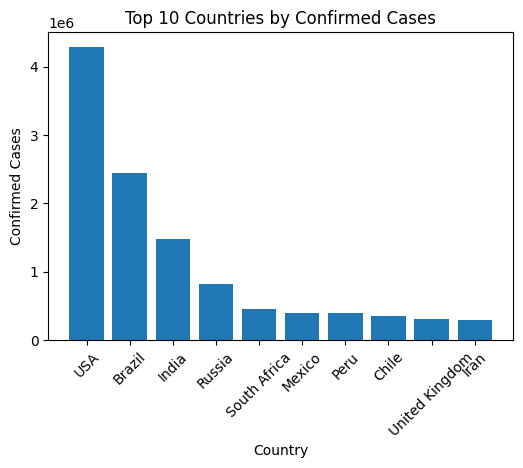

In [20]:
top_confirmed_pd = top_confirmed.toPandas()
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(top_confirmed_pd["Country/Region"], top_confirmed_pd["Confirmed"])
plt.xticks(rotation=45)
plt.title("Top 10 Countries by Confirmed Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.show()

#### Task 6: Top 10 Countries by Death Rate

In [21]:
death_rate = country_latest.select(
    col("Country/Region"),
    col("Deaths / 100 Cases")
).orderBy(
    col("Deaths / 100 Cases").desc()
).limit(10)

death_rate.show()

+--------------+------------------+
|Country/Region|Deaths / 100 Cases|
+--------------+------------------+
|         Yemen|             28.56|
|United Kingdom|             15.19|
|       Belgium|             14.79|
|         Italy|             14.26|
|        France|             13.71|
|       Hungary|              13.4|
|   Netherlands|             11.53|
|        Mexico|             11.13|
|         Spain|             10.44|
|Western Sahara|              10.0|
+--------------+------------------+



In [27]:
print(death_rate.columns)

['Country/Region', 'Deaths / 100 Cases']


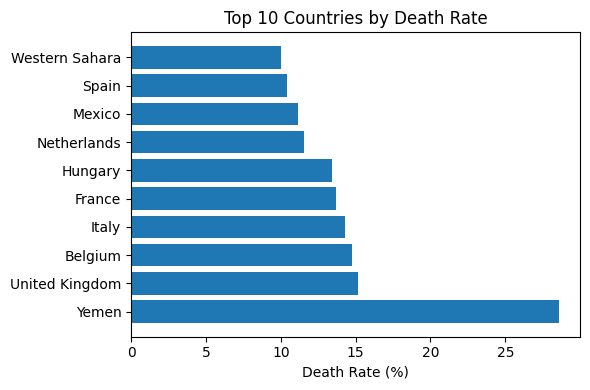

In [30]:
plt.figure(figsize=(6,4))

plt.barh(
    death_rate_pd["Country/Region"],
    death_rate_pd["Deaths / 100 Cases"]
)

plt.title("Top 10 Countries by Death Rate")
plt.xlabel("Death Rate (%)")
plt.tight_layout()
plt.show()

#### Task 7: WHO Region-wise Total Cases

In [23]:
from pyspark.sql.functions import sum

who_region_stats = full_grouped.groupBy("WHO Region").agg(
    sum("Confirmed").alias("Total_Confirmed"),
    sum("Deaths").alias("Total_Deaths"),
    sum("Recovered").alias("Total_Recovered")
)

who_region_stats.show()

+--------------------+---------------+------------+---------------+
|          WHO Region|Total_Confirmed|Total_Deaths|Total_Recovered|
+--------------------+---------------+------------+---------------+
|              Europe|      248879793|    19271040|      123202075|
|     Western Pacific|       26374411|      932430|       18861950|
|              Africa|       21791827|      439978|       11193730|
|Eastern Mediterra...|       74082892|     1924029|       48050703|
|            Americas|      402261194|    19359292|      157069444|
|     South-East Asia|       55118365|     1458134|       30030327|
+--------------------+---------------+------------+---------------+



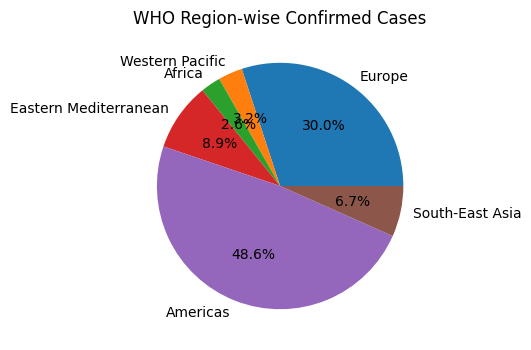

In [25]:
who_pd = who_region_stats.toPandas()

plt.figure(figsize=(6,4))
plt.pie(
    who_pd["Total_Confirmed"],
    labels=who_pd["WHO Region"],
    autopct="%1.1f%%"
)
plt.title("WHO Region-wise Confirmed Cases")
plt.show()

### ***Phase 4***
- Time-Series Analysis

#### Task 8: Daily Global New Cases Trend

In [31]:
day_wise.printSchema()
day_wise.show(5)

root
 |-- Date: date (nullable = true)
 |-- Confirmed: integer (nullable = true)
 |-- Deaths: integer (nullable = true)
 |-- Recovered: integer (nullable = true)
 |-- Active: integer (nullable = true)
 |-- New cases: integer (nullable = true)
 |-- New deaths: integer (nullable = true)
 |-- New recovered: integer (nullable = true)
 |-- Deaths / 100 Cases: double (nullable = true)
 |-- Recovered / 100 Cases: double (nullable = true)
 |-- Deaths / 100 Recovered: double (nullable = true)
 |-- No. of countries: integer (nullable = true)

+----------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+----------------------+----------------+
|      Date|Confirmed|Deaths|Recovered|Active|New cases|New deaths|New recovered|Deaths / 100 Cases|Recovered / 100 Cases|Deaths / 100 Recovered|No. of countries|
+----------+---------+------+---------+------+---------+----------+-------------+------------------+---------------------+-------------

In [56]:
daily_cases = day_wise.select(
    "Date",
    "New cases"
)

daily_cases.show()

+----------+---------+
|      Date|New cases|
+----------+---------+
|2020-01-22|        0|
|2020-01-23|       99|
|2020-01-24|      287|
|2020-01-25|      493|
|2020-01-26|      684|
|2020-01-27|      809|
|2020-01-28|     2651|
|2020-01-29|      588|
|2020-01-30|     2068|
|2020-01-31|     1693|
|2020-02-01|     2111|
|2020-02-02|     4749|
|2020-02-03|     3100|
|2020-02-04|     4011|
|2020-02-05|     3745|
|2020-02-06|     3159|
|2020-02-07|     3532|
|2020-02-08|     2734|
|2020-02-09|     3027|
|2020-02-10|     2538|
+----------+---------+
only showing top 20 rows


In [57]:
daily_cases_pd = daily_cases.toPandas()

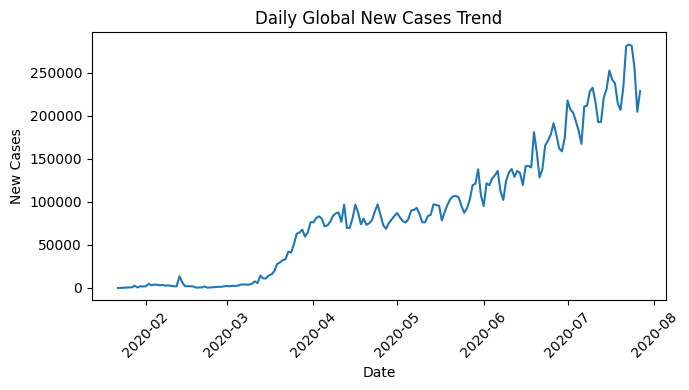

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))

plt.plot(
    daily_cases_pd["Date"],
    daily_cases_pd["New cases"]
)

plt.xticks(rotation=45)
plt.title("Daily Global New Cases Trend")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.tight_layout()
plt.show()

#### Task 9: Daily Global Death Growth Trend

In [60]:
from pyspark.sql.functions import when, col, round
from pyspark.sql.window import Window
from pyspark.sql.functions import lag

windowSpec = Window.orderBy("Date")

death_growth = day_wise.withColumn(
    "Previous_Deaths",
    lag("New deaths", 1).over(windowSpec)
)

death_growth = death_growth.withColumn(
    "Death_Growth_Percentage",
    when(
        (col("Previous_Deaths").isNull()) | (col("Previous_Deaths") == 0),
        None
    ).otherwise(
        round(
            (col("New deaths") / col("Previous_Deaths")) * 100,
            2
        )
    )
)

death_growth.select(
    "Date",
    "New deaths",
    "Previous_Deaths",
    "Death_Growth_Percentage"
).show()

+----------+----------+---------------+-----------------------+
|      Date|New deaths|Previous_Deaths|Death_Growth_Percentage|
+----------+----------+---------------+-----------------------+
|2020-01-22|         0|           NULL|                   NULL|
|2020-01-23|         1|              0|                   NULL|
|2020-01-24|         8|              1|                  800.0|
|2020-01-25|        16|              8|                  200.0|
|2020-01-26|        14|             16|                   87.5|
|2020-01-27|        26|             14|                 185.71|
|2020-01-28|        49|             26|                 188.46|
|2020-01-29|         2|             49|                   4.08|
|2020-01-30|        38|              2|                 1900.0|
|2020-01-31|        42|             38|                 110.53|
|2020-02-01|        46|             42|                 109.52|
|2020-02-02|       103|             46|                 223.91|
|2020-02-03|        64|            103| 

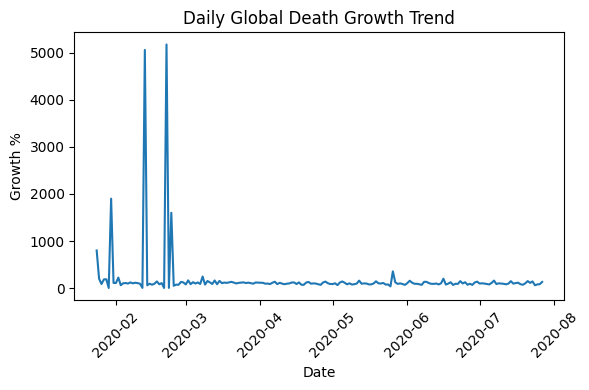

In [61]:
death_growth_pd = death_growth.select(
    "Date",
    "Death_Growth_Percentage"
).toPandas()

plt.figure(figsize=(6,4))

plt.plot(
    death_growth_pd["Date"],
    death_growth_pd["Death_Growth_Percentage"]
)

plt.xticks(rotation=45)
plt.title("Daily Global Death Growth Trend")
plt.xlabel("Date")
plt.ylabel("Growth %")
plt.tight_layout()
plt.show()

#### Task 10: Covid case growth monthly

In [62]:
from pyspark.sql.functions import month, to_date, sum
full_grouped = full_grouped.withColumn(
    "Date",
    to_date(col("Date"), "yyyy-MM-dd")
)

monthly_cases = full_grouped.withColumn(
    "Month",
    month("Date")
)

monthly_cases = monthly_cases.groupBy("Month").agg(
    sum("Confirmed").alias("Total_Confirmed")
).orderBy("Month")

monthly_cases.show()

+-----+---------------+
|Month|Total_Confirmed|
+-----+---------------+
|    1|          38534|
|    2|        1663437|
|    3|        9002815|
|    4|       63391662|
|    5|      144990399|
|    6|      246525787|
|    7|      362895848|
+-----+---------------+



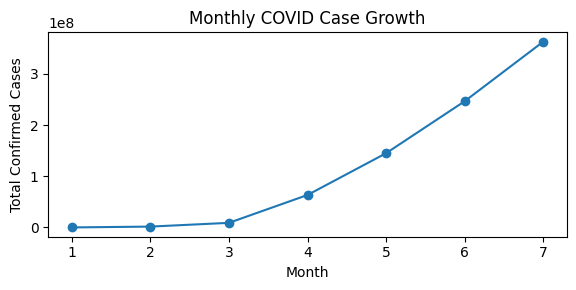

In [63]:
monthly_pd = monthly_cases.toPandas()

plt.figure(figsize=(6,3))

plt.plot(
    monthly_pd["Month"],
    monthly_pd["Total_Confirmed"],
    marker='o'
)

plt.title("Monthly COVID Case Growth")
plt.xlabel("Month")
plt.ylabel("Total Confirmed Cases")
plt.tight_layout()
plt.show()